In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
FAKE_PATH = '/content/fake.csv'
TRUE_PATH = '/content/true.csv'
fake_df = pd.read_csv(FAKE_PATH)
true_df = pd.read_csv(TRUE_PATH)

print(f'Fake news articles : {len(fake_df)}')
print(f'True news articles : {len(true_df)}')
print(f'\nFake columns: {fake_df.columns.tolist()}')
print(f'True columns: {true_df.columns.tolist()}')

Fake news articles : 23481
True news articles : 21417

Fake columns: ['title', 'text', 'subject', 'date']
True columns: ['title', 'text', 'subject', 'date']


In [ ]:
print('=== FAKE NEWS - First 2 rows ===')
display(fake_df.head(2))
print('\n=== TRUE NEWS - First 2 rows ===')
display(true_df.head(2))

=== FAKE NEWS - First 2 rows ===


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"



=== TRUE NEWS - First 2 rows ===


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"


In [ ]:
print('Null values in Fake:')
print(fake_df.isnull().sum())
print('\nNull values in True:')
print(true_df.isnull().sum())

Null values in Fake:
title      0
text       0
subject    0
date       0
dtype: int64

Null values in True:
title      0
text       0
subject    0
date       0
dtype: int64


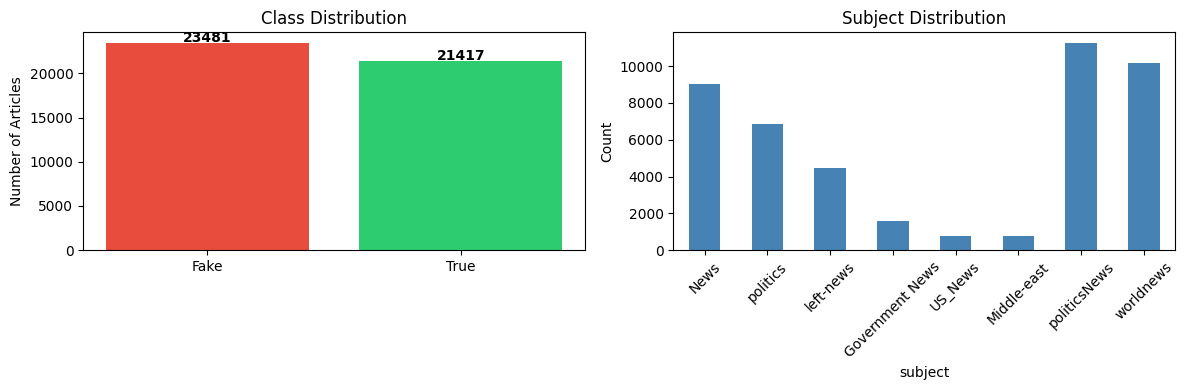

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Fake', 'True'], [len(fake_df), len(true_df)], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate([len(fake_df), len(true_df)]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Subject distribution
fake_subjects = fake_df['subject'].value_counts()
true_subjects = true_df['subject'].value_counts()
all_subjects = pd.concat([fake_subjects, true_subjects])
all_subjects.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Subject Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Add labels: 0 = Fake, 1 = True
fake_df['label'] = 0
true_df['label'] = 1

# Combine into single dataframe
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

# Drop subject and date (subject causes data leakage, date has no signal)
df.drop(columns=['subject', 'date'], inplace=True)

print(f'Combined dataset shape: {df.shape}')
print(f'Label distribution:\n{df["label"].value_counts()}')
display(df.head(3))

Combined dataset shape: (44898, 3)
Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0


In [ ]:
def clean_text(text):
    """Clean and normalize text"""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine title + text for richer features
df['content'] = df['title'] + ' ' + df['text']
df['content'] = df['content'].apply(clean_text)

print('Sample cleaned content:')
print(df['content'].iloc[0][:200])

Sample cleaned content:
donald trump sends out embarrassing new year’s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to 


In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

X = df['content']
y = df['label']

# Train / Validation / Test split: 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train size : {len(X_train)}')
print(f'Val size   : {len(X_val)}')
print(f'Test size  : {len(X_test)}')

Train size : 31428
Val size   : 6735
Test size  : 6735


In [ ]:
# TF-IDF with unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),       # unigrams and bigrams
    stop_words='english',
    sublinear_tf=True         # apply log normalization to TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')

TF-IDF matrix shape (train): (31428, 5000)
Vocabulary size: 5000


In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, evaluate and return results for a model"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc     = accuracy_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_prob) if y_prob is not None else 'N/A'

    print(f'\n{"-"*50}')
    print(f'  {name}')
    print(f'{"-"*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  ROC-AUC   : {roc_auc:.4f}' if roc_auc != 'N/A' else '  ROC-AUC : N/A')
    print(f'\n  Classification Report:')
    print(classification_report(y_te, y_pred, target_names=['Fake', 'True']))

    return model, y_pred, y_prob, acc, roc_auc

In [ ]:
lr_model, lr_pred, lr_prob, lr_acc, lr_auc = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_tfidf, y_train,
    X_test_tfidf, y_test
)


--------------------------------------------------
  Logistic Regression
--------------------------------------------------
  Accuracy  : 0.9929
  ROC-AUC   : 0.9995

  Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3523
        True       0.99      0.99      0.99      3212

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



In [ ]:
# --- Model 2: Passive Aggressive Classifier ---
# Note: PAC does not support predict_proba natively
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train_tfidf, y_train)
pac_pred = pac.predict(X_test_tfidf)
pac_acc  = accuracy_score(y_test, pac_pred)

print(f'\n{"-"*50}')
print(f'  Passive Aggressive Classifier')
print(f'{"-"*50}')
print(f'  Accuracy : {pac_acc:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, pac_pred, target_names=['Fake', 'True']))


--------------------------------------------------
  Passive Aggressive Classifier
--------------------------------------------------
  Accuracy : 0.9967

  Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3523
        True       1.00      1.00      1.00      3212

    accuracy                           1.00      6735
   macro avg       1.00      1.00      1.00      6735
weighted avg       1.00      1.00      1.00      6735



In [ ]:
# --- Model 3: Random Forest ---
# Uses fewer estimators to keep Colab runtime reasonable
rf_model, rf_pred, rf_prob, rf_acc, rf_auc = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_tfidf, y_train,
    X_test_tfidf, y_test
)


--------------------------------------------------
  Random Forest
--------------------------------------------------
  Accuracy  : 0.9973
  ROC-AUC   : 0.9999

  Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3523
        True       1.00      1.00      1.00      3212

    accuracy                           1.00      6735
   macro avg       1.00      1.00      1.00      6735
weighted avg       1.00      1.00      1.00      6735



In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Passive Aggressive', 'Random Forest'],
    'Accuracy': [lr_acc, pac_acc, rf_acc],
    'ROC-AUC': [lr_auc, 'N/A', rf_auc]
})
results['Accuracy'] = results['Accuracy'].apply(lambda x: f'{x:.4f}')
print('\n=== Model Comparison ===')
display(results)


=== Model Comparison ===


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.9929,0.999474
1,Passive Aggressive,0.9967,N/A
2,Random Forest,0.9973,0.999906


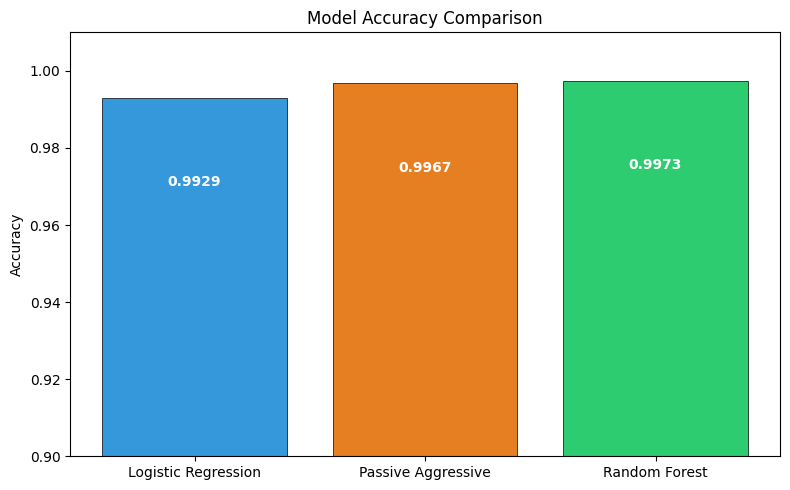

In [ ]:
# Accuracy comparison bar chart
models   = ['Logistic Regression', 'Passive Aggressive', 'Random Forest']
accs     = [lr_acc, pac_acc, rf_acc]
colors   = ['#3498db', '#e67e22', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=colors, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
             f'{acc:.4f}', ha='center', va='top', color='white', fontweight='bold')
plt.ylim(0.9, 1.01)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.tight_layout()
plt.show()

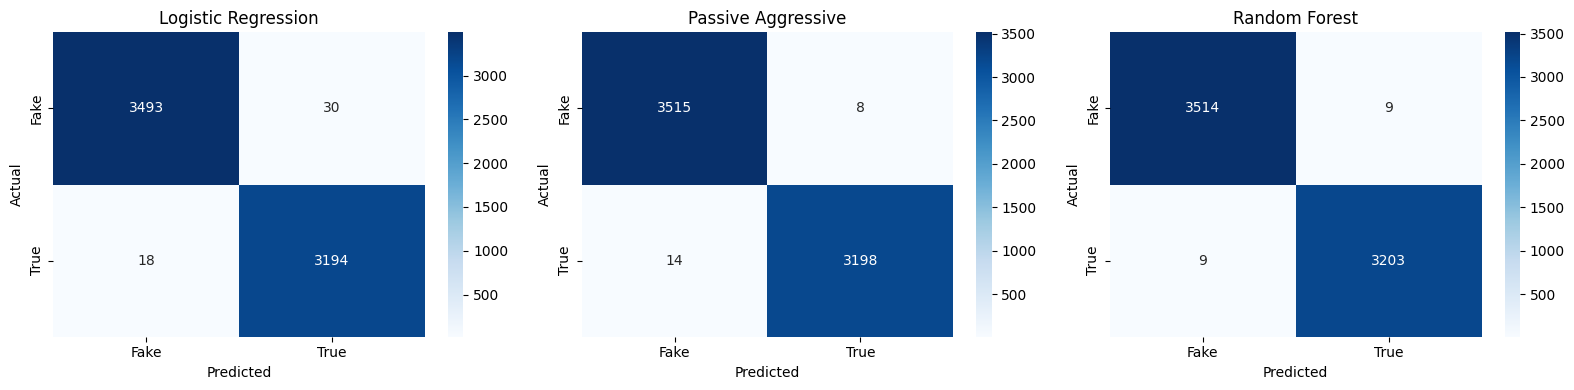

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = ['Logistic Regression', 'Passive Aggressive', 'Random Forest']
preds       = [lr_pred, pac_pred, rf_pred]

for ax, name, pred in zip(axes, model_names, preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fake', 'True'],
                yticklabels=['Fake', 'True'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

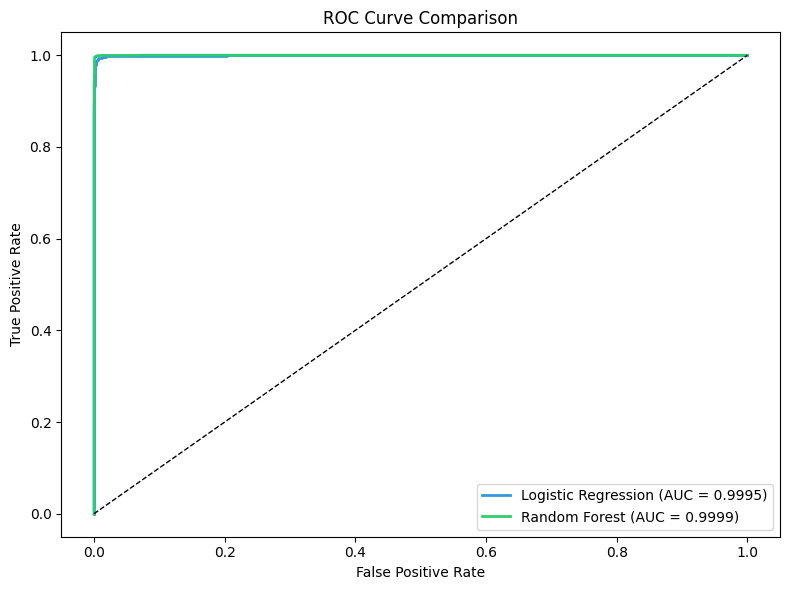

In [ ]:
# ROC Curve (LR and RF only — PAC has no predict_proba)
plt.figure(figsize=(8, 6))

for name, prob, color in [
    ('Logistic Regression', lr_prob, '#3498db'),
    ('Random Forest',       rf_prob, '#2ecc71')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

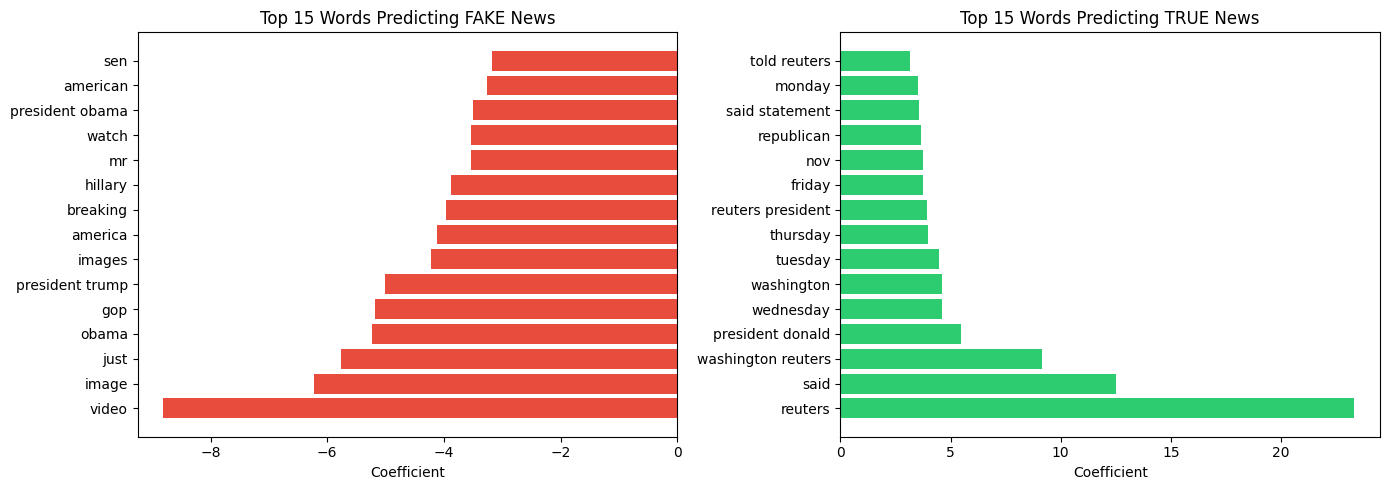

In [ ]:
feature_names = tfidf.get_feature_names_out()
coef          = lr_model.coef_[0]

top_n = 15
top_fake_idx = coef.argsort()[:top_n]           # most negative = fake
top_true_idx = coef.argsort()[-top_n:][::-1]    # most positive = true

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_fake_idx], coef[top_fake_idx], color='#e74c3c')
axes[0].set_title('Top 15 Words Predicting FAKE News')
axes[0].set_xlabel('Coefficient')

axes[1].barh(feature_names[top_true_idx], coef[top_true_idx], color='#2ecc71')
axes[1].set_title('Top 15 Words Predicting TRUE News')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

In [ ]:
# Save best model (Logistic Regression typically wins on this dataset)
# Change lr_model to rf_model or pac if they performed better for you
joblib.dump(lr_model, '/content/drive/MyDrive/fake_news/best_model.pkl')
joblib.dump(tfidf,    '/content/drive/MyDrive/fake_news/tfidf_vectorizer.pkl')

print('Model and vectorizer saved to Google Drive!')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/fake_news/best_model.pkl'

In [ ]:
def predict_news(title, text, model, vectorizer):
    """Predict whether a news article is fake or true"""
    content = clean_text(title + ' ' + text)
    vec     = vectorizer.transform([content])
    pred    = model.predict(vec)[0]
    prob    = model.predict_proba(vec)[0]

    label   = 'TRUE' if pred == 1 else 'FAKE'
    conf    = prob[pred]

    print(f'Prediction  : {label}')
    print(f'Confidence  : {conf:.2%}')
    print(f'Fake prob   : {prob[0]:.2%}')
    print(f'True prob   : {prob[1]:.2%}')
    return label

# --- Test with a sample article ---
sample_title = "Scientists discover cure for common cold"
sample_text  = "Researchers at a leading university have announced a breakthrough treatment that eliminates cold symptoms within 24 hours in clinical trials."

predict_news(sample_title, sample_text, lr_model, tfidf)

Prediction  : FAKE
Confidence  : 87.07%
Fake prob   : 87.07%
True prob   : 12.93%


'FAKE'